# AAI614: Data Science & its Applications

*Notebook 5.4: Experiment with KNN*

<a href="https://colab.research.google.com/github/harmanani/AAI614/blob/main/Week%205/Notebook5.4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Example I: Classifying Social Networks Ads

## Importing the libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [ ]:
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

dataset = pd.read_csv('https://raw.githubusercontent.com/harmanani/AAI614/main/Week%205/Social_Network_Ads.csv')
X = dataset.iloc[:, [2, 3]].values
y = dataset.iloc[:, 4].values

## Splitting the dataset into the Training set and Test set

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)


## Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Fitting K-NN to the Training set

Use the KNN model for training by specifying the input and output variables of the training set as follows.  Note that *p =2* refers to **euclidean distance**.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
classifier.fit(X_train, y_train)

## Predicting the Test set results

In [ ]:
y_pred = classifier.predict(X_test)

## Making the Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

# Example II: Classifying Digits

In [ ]:
from sklearn import metrics

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
# Train the model using the training sets
x_train, x_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.25)

In [ ]:
digits = load_digits()
# Train the model using the training sets
x_train, x_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.25)

In [ ]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)

In [ ]:
#Predict Output
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, model.predict(x_test))
score = model.score(x_test, y_test)

In [ ]:
import seaborn as sns
plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5,square = True, cmap = 'YlGnBu')
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(score)
plt.title(all_sample_title, size = 15);

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Example 3: Diabetes Data set


In [29]:
#Importing the dataset
dataset_diabetes = pd.read_csv("diabetes.csv")
dataset_diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [30]:
#Separate Features (X) and Target (y)
X = dataset_diabetes.loc[:, dataset.columns != "Outcome"].values
y = dataset_diabetes.loc[:, "Outcome"].values

In [31]:

#Split the Dataset into Training and Testing Sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=0
)


In [32]:

#check the sizes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((576, 8), (192, 8), (576,), (192,))

In [33]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [34]:
X_train[:5]

array([[ 1.50755225, -1.01521454, -0.40451932, -1.31921491, -0.71823753,
        -1.22070104, -0.98325882, -0.04863985],
       [-0.82986389, -0.09964691, -0.61509602,  0.9287299 ,  0.08374747,
         0.13719053, -0.62493647, -0.88246592],
       [-1.12204091, -0.95207195,  0.54307587, -1.31921491, -0.71823753,
         0.0240329 ,  0.39884168, -0.5489355 ],
       [ 2.38408331,  0.59492164,  0.64836422,  1.36583027,  2.05458297,
         0.87900167,  0.17903049,  2.03592532],
       [ 1.50755225,  0.75277813,  0.54307587,  1.55315901,  0.39089067,
         0.71555175,  0.50724171,  0.53503839]])

In [35]:
#Train the KNN model
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2
)

classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [36]:
#Predict the Test Set Results
y_pred = classifier.predict(X_test)

In [37]:
#see a few predictions
y_pred[:10]

array([1, 0, 0, 1, 0, 0, 1, 1, 1, 0])

In [38]:
#Evaluate the Model Using Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[114,  16],
       [ 22,  40]])

In [39]:
#calculate accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8020833333333334


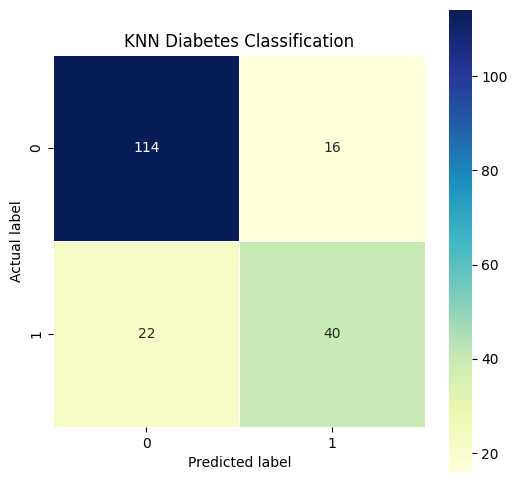

In [40]:
#heatmap visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    linewidths=0.5,
    square=True,
    cmap="YlGnBu"
)

plt.ylabel("Actual label")
plt.xlabel("Predicted label")

plt.title("KNN Diabetes Classification")
plt.show()

Summary: The KNN model successfully classified diabetes outcomes with an accuracy of 80.2%. Feature scaling helped improve the distance-based algorithm, and the confusion matrix showed the model's correct and incorrect predictions. This experiment demonstrates how KNN can be used for medical classification problems.